# Student Academic Advisor — Part B: K-Means Clustering

**Course:** Basic of AI Programming Skills (DSC 311)  
**Dataset:** UCI Student Performance (`student-por.csv`)  
**Purpose:** Reproduce and explain the approved Part B pipeline using the tested project modules.

> This notebook is an academic presentation layer. The reusable implementation remains inside `student_academic_advisor/ml_pipeline/`.

## Analysis plan

1. Load and understand the approved dataset.
2. Audit duplicates and missing values.
3. Select the approved clustering features.
4. Standardize the features.
5. evaluate candidate values of $K$ using inertia and Silhouette Score.
6. Fit the final deterministic K-Means model.
7. Interpret clusters only after training.
8. Use `G3` only for post-hoc checking, never for training.
9. Relate the observed population patterns to Part A without coupling the two implementations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def find_project_root() -> Path:
    """Find the repository whether Jupyter starts in root or notebooks/."""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        package = candidate / "student_academic_advisor"
        dataset = candidate / "data/raw/uci_student_performance/student-por.csv"
        if package.is_dir() and dataset.is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find the project root. Open this notebook from inside "
        "the student-academic-advisor repository."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_PATH = PROJECT_ROOT / "data/raw/uci_student_performance/student-por.csv"
PROJECT_ROOT, DATASET_PATH

(WindowsPath('F:/المنهج/Summer/Basic of AI programming/Project/student-academic-advisor'),
 WindowsPath('F:/المنهج/Summer/Basic of AI programming/Project/student-academic-advisor/data/raw/uci_student_performance/student-por.csv'))

In [2]:
from student_academic_advisor.ml_pipeline.clustering import (
    N_INIT,
    RANDOM_STATE,
    evaluate_k_candidates,
    fit_final_kmeans,
    select_k_by_silhouette,
)
from student_academic_advisor.ml_pipeline.data_preparation import (
    FEATURE_COLUMNS,
    POST_HOC_COLUMN,
    prepare_student_data,
)
from student_academic_advisor.ml_pipeline.reporting import (
    build_cluster_profiles,
    derive_profile_labels,
)

## 1. Dataset understanding

The [UCI Student Performance dataset](https://archive.ics.uci.edu/dataset/320/student+performance) describes student achievement in two Portuguese secondary schools. This project uses the Portuguese-language course file, which contains 649 records and 33 original columns. The UCI repository reports no missing values and provides both Mathematics and Portuguese subject files.

The approved clustering variables are:

| Feature | Meaning | Role |
|---|---|---|
| `G1` | First-period grade, 0–20 | Training |
| `G2` | Second-period grade, 0–20 | Training |
| `absences` | Number of school absences | Training |
| `studytime` | Ordinal weekly study-time category, 1–4 | Training |
| `failures` | Number of previous class failures in the observed data, 0–3 | Training |
| `G3` | Final grade, 0–20 | Post-hoc only |

`G3` is deliberately excluded from clustering to avoid using the final outcome to create the student groups.

**Dataset citation:** Cortez, P. (2008). *Student Performance* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T

In [3]:
raw_data = pd.read_csv(DATASET_PATH, sep=";")
print(f"Dataset shape: {raw_data.shape[0]} rows × {raw_data.shape[1]} columns")
raw_data.head()

Dataset shape: 649 rows × 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
approved_columns = [*FEATURE_COLUMNS, POST_HOC_COLUMN]
raw_data.loc[:, approved_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
G1,649.0,11.399076,2.745265,0.0,10.0,11.0,13.0,19.0
G2,649.0,11.570108,2.913639,0.0,10.0,11.0,13.0,19.0
absences,649.0,3.659476,4.640759,0.0,0.0,2.0,6.0,32.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
G3,649.0,11.906009,3.230656,0.0,10.0,12.0,14.0,19.0


## 2. Data-quality audit

The pipeline checks missing values and exact duplicate rows explicitly. A zero count is still an observed audit result; it does not mean the check was skipped.

In [5]:
audit_table = pd.DataFrame(
    {
        "missing_values": raw_data.loc[:, approved_columns].isna().sum(),
        "data_type": raw_data.loc[:, approved_columns].dtypes.astype(str),
    }
)
duplicate_count = int(raw_data.duplicated().sum())
print(f"Exact duplicate rows: {duplicate_count}")
audit_table

Exact duplicate rows: 0


,missing_values,data_type
G1,0,int64
G2,0,int64
absences,0,int64
studytime,0,int64
failures,0,int64
G3,0,int64


In [6]:
prepared = prepare_student_data(DATASET_PATH)
pd.Series(
    {
        "original_rows": prepared.audit.original_rows,
        "cleaned_rows": prepared.audit.cleaned_rows,
        "duplicate_rows_removed": prepared.audit.duplicate_rows_removed,
        "missing_rows_removed": prepared.audit.missing_rows_removed,
        "selected_features": ", ".join(prepared.audit.selected_features),
    },
    name="Data audit",
)

original_rows                                               649
cleaned_rows                                                649
duplicate_rows_removed                                        0
missing_rows_removed                                          0
selected_features         G1, G2, absences, studytime, failures
Name: Data audit, dtype: object

## 3. Feature selection, encoding, and scaling

No categorical encoding is required because all five approved features are numeric or ordinal numeric fields. K-Means uses Euclidean distance, so the features are standardized with `StandardScaler` to stop a large numeric range from dominating the distance calculation.

For each feature $x$, standardization calculates:

$$z = \frac{x - \mu}{\sigma}$$

Because this is unsupervised population clustering rather than predictive testing, the scaler is fitted to the clustering feature matrix. `G3` never enters that matrix.

In [7]:
print("Raw feature ranges:")
prepared.raw_features.agg(["min", "max", "mean", "std"]).T

Raw feature ranges:


,min,max,mean,std
G1,0.0,19.0,11.399076,2.745265
G2,0.0,19.0,11.570108,2.913639
absences,0.0,32.0,3.659476,4.640759
studytime,1.0,4.0,1.930663,0.829510
failures,0.0,3.0,0.221880,0.593235


In [8]:
scaled_frame = pd.DataFrame(
    prepared.scaled_features,
    columns=FEATURE_COLUMNS,
)
scaled_frame.agg(["mean", "std", "min", "max"]).T.round(4)

,mean,std,min,max
G1,0.0,1.0008,-4.1555,2.7709
G2,-0.0,1.0008,-3.9741,2.5520
absences,0.0,1.0008,-0.7892,6.1116
studytime,0.0,1.0008,-1.1228,2.4966
failures,0.0,1.0008,-0.3743,4.6866


## 4. Selecting the number of clusters

### How K-Means works

For a chosen value of K, K-Means repeats four main steps:

1. Initialize K centroids.
2. Assign every student to the nearest centroid using Euclidean distance.
3. Recalculate each centroid as the mean of the students assigned to it.
4. Repeat assignment and centroid updates until the solution stabilizes.

The algorithm minimizes the within-cluster sum of squared distances:

$$\text{Inertia} = \sum_{i=1}^{n} \lVert x_i - \mu_{c_i} \rVert^2$$

where $x_i$ is a standardized student record and $\mu_{c_i}$ is the centroid assigned to that student.

### K evaluation

Candidate values from $K=2$ to $K=10$ are compared using two measures:

- **Inertia:** the within-cluster sum of squared distances. Lower values indicate more compact clusters, but inertia always decreases as K increases.
- **Silhouette Score:** combines cohesion and separation. Higher values are better, with values near zero indicating overlapping groups.

All runs use `random_state=42` and `n_init=20` for reproducibility. The approved selection rule chooses the highest Silhouette Score and prefers the smaller K only on an exact tie.

In [9]:
metrics = evaluate_k_candidates(prepared.scaled_features)
metrics_frame = pd.DataFrame(
    [
        {"K": metric.k, "Inertia": metric.inertia, "Silhouette": metric.silhouette}
        for metric in metrics
    ]
)
metrics_frame.round({"Inertia": 3, "Silhouette": 4})

,K,Inertia,Silhouette
0,2,2302.167,0.2717
1,3,1848.916,0.2624
2,4,1563.691,0.2709
3,5,1330.206,0.2694
4,6,1175.209,0.2582
5,7,1067.264,0.2528
6,8,997.714,0.2469
7,9,925.246,0.2499
8,10,866.953,0.2555


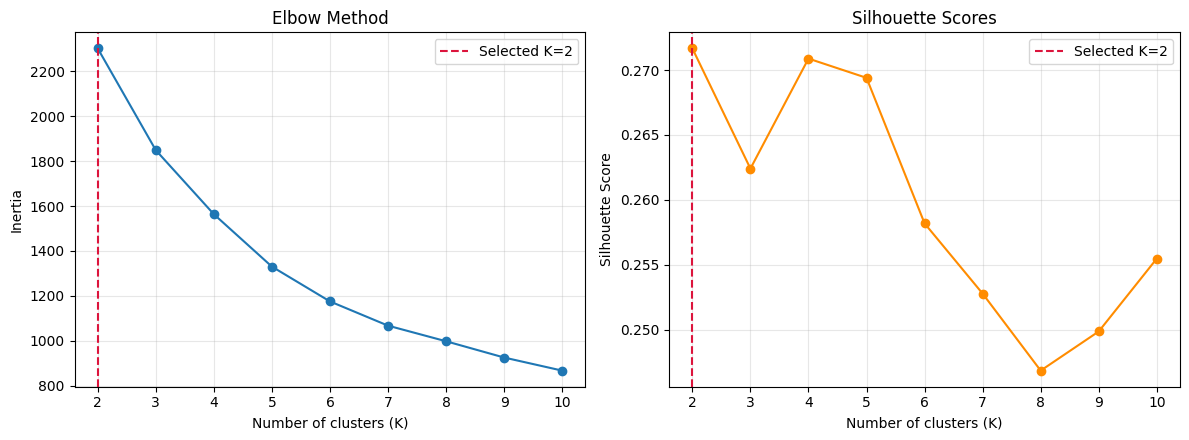

Selected K: 2
Selected Silhouette Score: 0.2717
Selected Inertia: 2302.167


In [10]:
selected_k = select_k_by_silhouette(metrics)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(metrics_frame["K"], metrics_frame["Inertia"], marker="o")
axes[0].axvline(selected_k, color="crimson", linestyle="--", label=f"Selected K={selected_k}")
axes[0].set(title="Elbow Method", xlabel="Number of clusters (K)", ylabel="Inertia")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    metrics_frame["K"],
    metrics_frame["Silhouette"],
    marker="o",
    color="darkorange",
)
axes[1].axvline(selected_k, color="crimson", linestyle="--", label=f"Selected K={selected_k}")
axes[1].set(title="Silhouette Scores", xlabel="Number of clusters (K)", ylabel="Silhouette Score")
axes[1].grid(alpha=0.3)
axes[1].legend()
figure.tight_layout()
plt.show()

selected_metric = next(metric for metric in metrics if metric.k == selected_k)
print(f"Selected K: {selected_k}")
print(f"Selected Silhouette Score: {selected_metric.silhouette:.4f}")
print(f"Selected Inertia: {selected_metric.inertia:.3f}")

### Selection decision

The final choice is **K = 2** because it has the highest observed Silhouette Score. The Elbow curve decreases gradually and does not show one unambiguous sharp elbow. K=4 is close in Silhouette Score, but it adds complexity without improving the measured separation.

A score around 0.27 indicates overlapping student patterns, not perfectly separated natural categories. K=2 is the best relative candidate tested; it is not proof that every student objectively belongs to one of two true types.

## 5. Final K-Means model

The final model is fitted using the selected K and the same reproducibility settings. Numeric cluster IDs have no inherent meaning, so descriptive labels are assigned only after the trained centroids are inspected.

In [11]:
clustering = fit_final_kmeans(prepared.scaled_features, selected_k)
profile_labels = derive_profile_labels(clustering.centers_scaled)
profiles = build_cluster_profiles(
    prepared.cleaned_data,
    clustering.labels,
    profile_labels,
)

print(f"Model settings: random_state={RANDOM_STATE}, n_init={N_INIT}")
pd.Series(clustering.labels).value_counts().sort_index().rename("student_count")

Model settings: random_state=42, n_init=20


0    332
1    317
Name: student_count, dtype: int64

In [12]:
profile_view = profiles.copy()
profile_view["profile_label"] = profile_view["profile_label"].str.replace("_", " ")
profile_view.round(
    {
        "G1": 3,
        "G2": 3,
        "absences": 3,
        "studytime": 3,
        "failures": 3,
        "g3_mean": 3,
        "g3_median": 1,
    }
)

,cluster,profile_label,G1,G2,absences,studytime,failures,student_count,g3_mean,g3_median
0,0,stronger academic profile,13.380,13.593,2.401,2.286,0.012,332,14.033,14.0
1,1,higher academic support need profile,9.325,9.451,4.978,1.558,0.442,317,9.678,10.0


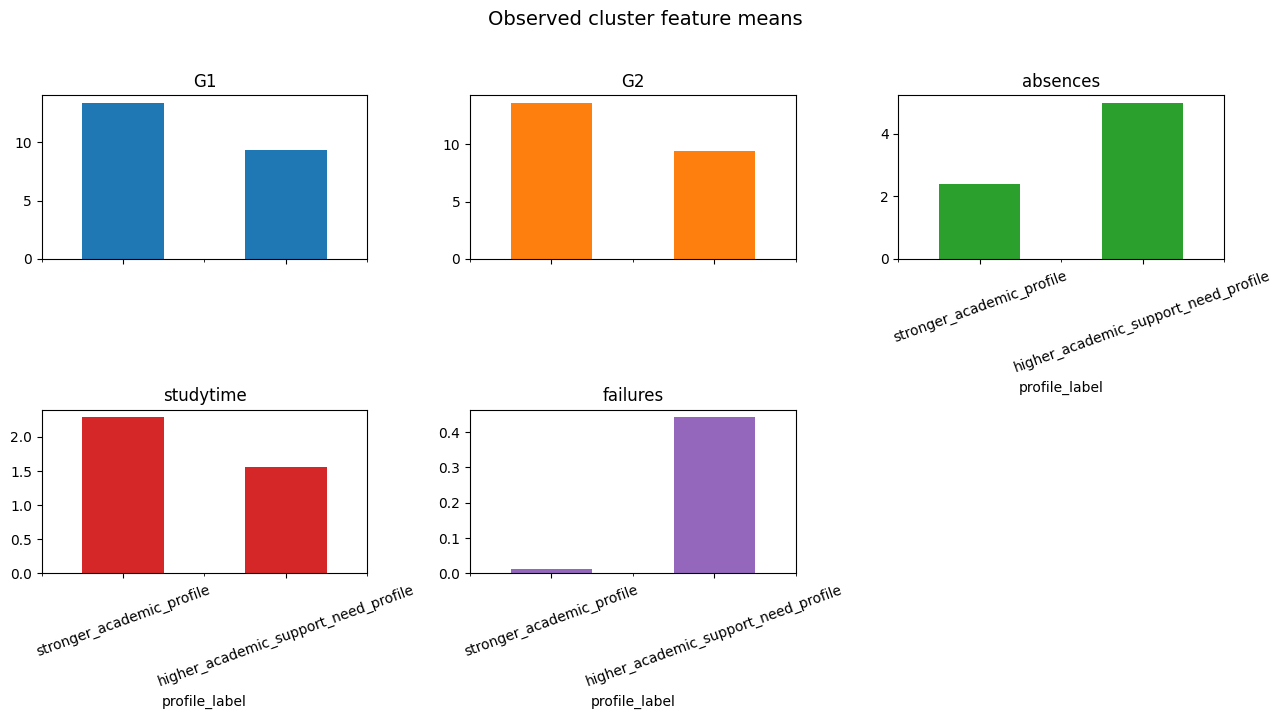

In [13]:
plot_profiles = profiles.set_index("profile_label")[list(FEATURE_COLUMNS)]
axes = plot_profiles.plot(
    kind="bar",
    subplots=True,
    layout=(2, 3),
    figsize=(13, 7),
    legend=False,
    title=list(FEATURE_COLUMNS),
)
for axis in np.asarray(axes).ravel():
    axis.tick_params(axis="x", rotation=20)
plt.suptitle("Observed cluster feature means", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Two-dimensional PCA view

The model was trained on all five standardized features. PCA is used below only to project those five dimensions into two dimensions for visualization; it does not change the trained K-Means model or its assignments. Some overlap is expected because a two-dimensional projection cannot preserve every relationship from the original feature space.

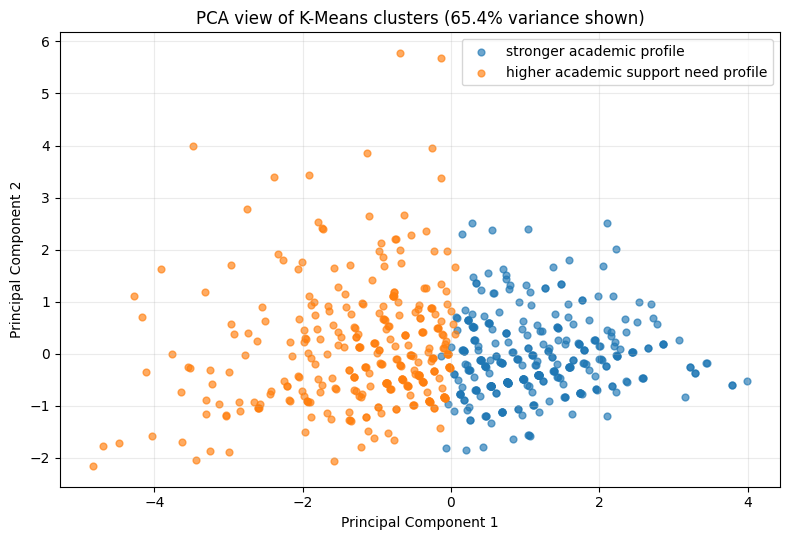

In [14]:
pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(prepared.scaled_features)
pca_frame = pd.DataFrame(pca_coordinates, columns=["PC1", "PC2"])
pca_frame["cluster"] = clustering.labels

figure, axis = plt.subplots(figsize=(8, 5.5))
for cluster_id in sorted(profile_labels):
    cluster_rows = pca_frame["cluster"] == cluster_id
    axis.scatter(
        pca_frame.loc[cluster_rows, "PC1"],
        pca_frame.loc[cluster_rows, "PC2"],
        s=24,
        alpha=0.65,
        label=profile_labels[cluster_id].replace("_", " "),
    )

explained_variance = pca.explained_variance_ratio_.sum()
axis.set(
    title=f"PCA view of K-Means clusters ({explained_variance:.1%} variance shown)",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2",
)
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

### Cluster interpretation

- **Stronger academic profile:** higher average G1 and G2, higher study time, fewer absences, and almost no previous failures.
- **Higher academic support-need profile:** lower average G1 and G2, lower study time, more absences, and more previous failures.

These are post-training descriptions of centroid patterns. They are not ground-truth labels and should not be presented as guaranteed individual diagnoses.

## 6. Post-hoc G3 check

`G3` was not used in scaling, K selection, or model fitting. It is examined only now to check whether the discovered groups have academically meaningful differences.

In [15]:
post_hoc = profiles[["profile_label", "student_count", "g3_mean", "g3_median"]].copy()
post_hoc["profile_label"] = post_hoc["profile_label"].str.replace("_", " ")
post_hoc.round({"g3_mean": 3, "g3_median": 1})

,profile_label,student_count,g3_mean,g3_median
0,stronger academic profile,332,14.033,14.0
1,higher academic support need profile,317,9.678,10.0


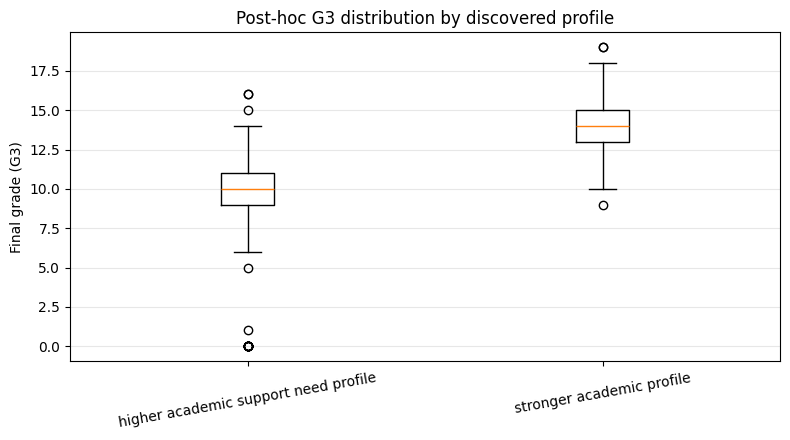

In [16]:
post_hoc_records = prepared.cleaned_data[[POST_HOC_COLUMN]].copy()
post_hoc_records["profile_label"] = pd.Series(clustering.labels).map(profile_labels)
ordered_labels = profiles.sort_values("g3_mean")["profile_label"].tolist()

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.boxplot(
    [
        post_hoc_records.loc[post_hoc_records["profile_label"] == label, POST_HOC_COLUMN]
        for label in ordered_labels
    ],
    tick_labels=[label.replace("_", " ") for label in ordered_labels],
)
axis.set(title="Post-hoc G3 distribution by discovered profile", ylabel="Final grade (G3)")
axis.tick_params(axis="x", rotation=10)
axis.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The post-hoc G3 difference supports the academic relevance of the discovered profiles while preserving the unsupervised nature of training. It does not turn the clusters into ground-truth classes.

## 7. Connection to Part A

Part A and Part B address the same advising domain from different perspectives:

| Part A — Expert System | Part B — K-Means |
|---|---|
| Reasons about one student | Finds patterns across the student population |
| Uses authored fuzzy rules | Uses distance-based unsupervised learning |
| Produces an explainable rule trace | Produces clusters and centroid profiles |
| Encodes domain knowledge | Discovers patterns without rule conclusions |

The higher-support cluster follows the same general concern directions used by Part A: lower period performance, lower study time, more absences, and more previous failures. This is a post-hoc comparison, not a forced code-level dependency and not proof that either output is ground truth.

## 8. Limitations

- The Silhouette Score indicates overlapping rather than sharply separated groups.
- K-Means assumes distance-based, roughly compact clusters and may not represent every structure in the data.
- `studytime` and `failures` are ordinal codes treated numerically as an explicit project decision.
- Cluster labels summarize average patterns and must not be treated as guaranteed judgments about individual students.
- The dataset represents students from two Portuguese schools, so conclusions should not automatically be generalized to every institution.
- Post-hoc G3 supports interpretation but does not prove causation.

## 9. Conclusion

The reproducible pipeline evaluated K from 2 to 10 and selected **K=2** using the highest observed Silhouette Score. The resulting clusters describe a stronger academic profile and a higher academic support-need profile. Their different post-hoc G3 summaries support the usefulness of the patterns, while the moderate Silhouette Score and the unsupervised nature of K-Means require cautious interpretation.